# 04 — Event Study

Computes Cumulative Abnormal Returns (CARs) for each ticker × event. This is the **core quantitative result** of the project.

**Prerequisite:** Run notebook 01 first.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import TICKERS, EVENT_DATES

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 4a. Run event study

In [2]:
import event_study
event_study.run()

2026-05-05 19:56:11,632  Loaded returns: 474 days × 9 tickers
2026-05-05 19:56:11,632  
── Event: teaser_trailer (2025-11-12) ──
2026-05-05 19:56:11,644    1913.HK     CAR = +0.0101  (beta=0.384)
2026-05-05 19:56:11,648    MC.PA       CAR = -0.0132  (beta=1.210)
2026-05-05 19:56:11,651    KER.PA      CAR = -0.0677  (beta=0.656)
2026-05-05 19:56:11,655    CPRI        CAR = +0.0505  (beta=2.447)
2026-05-05 19:56:11,658    TPR         CAR = +0.0283  (beta=1.687)
2026-05-05 19:56:11,661    EL          CAR = +0.0090  (beta=1.739)
2026-05-05 19:56:11,662  
── Event: full_trailer (2026-02-01) ──
2026-05-05 19:56:11,665    1913.HK     CAR = +0.0550  (beta=0.639)
2026-05-05 19:56:11,677    MC.PA       CAR = -0.0246  (beta=1.224)
2026-05-05 19:56:11,680    KER.PA      CAR = -0.0185  (beta=0.671)
2026-05-05 19:56:11,683    CPRI        CAR = -0.1534  (beta=1.146)
2026-05-05 19:56:11,687    TPR         CAR = +0.1798  (beta=1.648)
2026-05-05 19:56:11,690    EL          CAR = -0.1789  (beta=1.293)
20

## 4b. Load results

In [3]:
car_df      = pd.read_csv('../data/processed/car_results.csv')
car_summary = pd.read_csv('../data/processed/car_summary.csv')

# Format for display
display_cols = ['ticker', 'event', 'total_car', 't_stat', 'p_value', 'significant', 'beta']
print(car_summary[display_cols].to_string(index=False))

 ticker              event  total_car    t_stat  p_value  significant     beta
1913.HK       full_trailer   0.054962  1.766421 0.120666        False 0.638562
1913.HK  musical_extension  -0.044736 -0.907411 0.394354        False 0.214884
1913.HK    musical_opening   0.077529  1.252643 0.250560        False 0.614352
1913.HK   musical_previews   0.084907  0.989649 0.355313        False 0.781018
1913.HK       nyc_premiere   0.012531  0.210966 0.838924        False 0.327184
1913.HK     teaser_trailer   0.010102  0.160261 0.877202        False 0.383752
1913.HK theatrical_release        NaN       NaN      NaN        False 0.492840
   CPRI       full_trailer  -0.153418 -1.045820 0.330408        False 1.145730
   CPRI  musical_extension   0.115181  1.248354 0.252035        False 2.301700
   CPRI    musical_opening   0.042222  0.772632 0.465023        False 0.798315
   CPRI   musical_previews  -0.759701 -1.139488 0.291986        False 0.982483
   CPRI       nyc_premiere   0.026578  0.428384 0.68

## 4c. CAR paths — all tickers by event

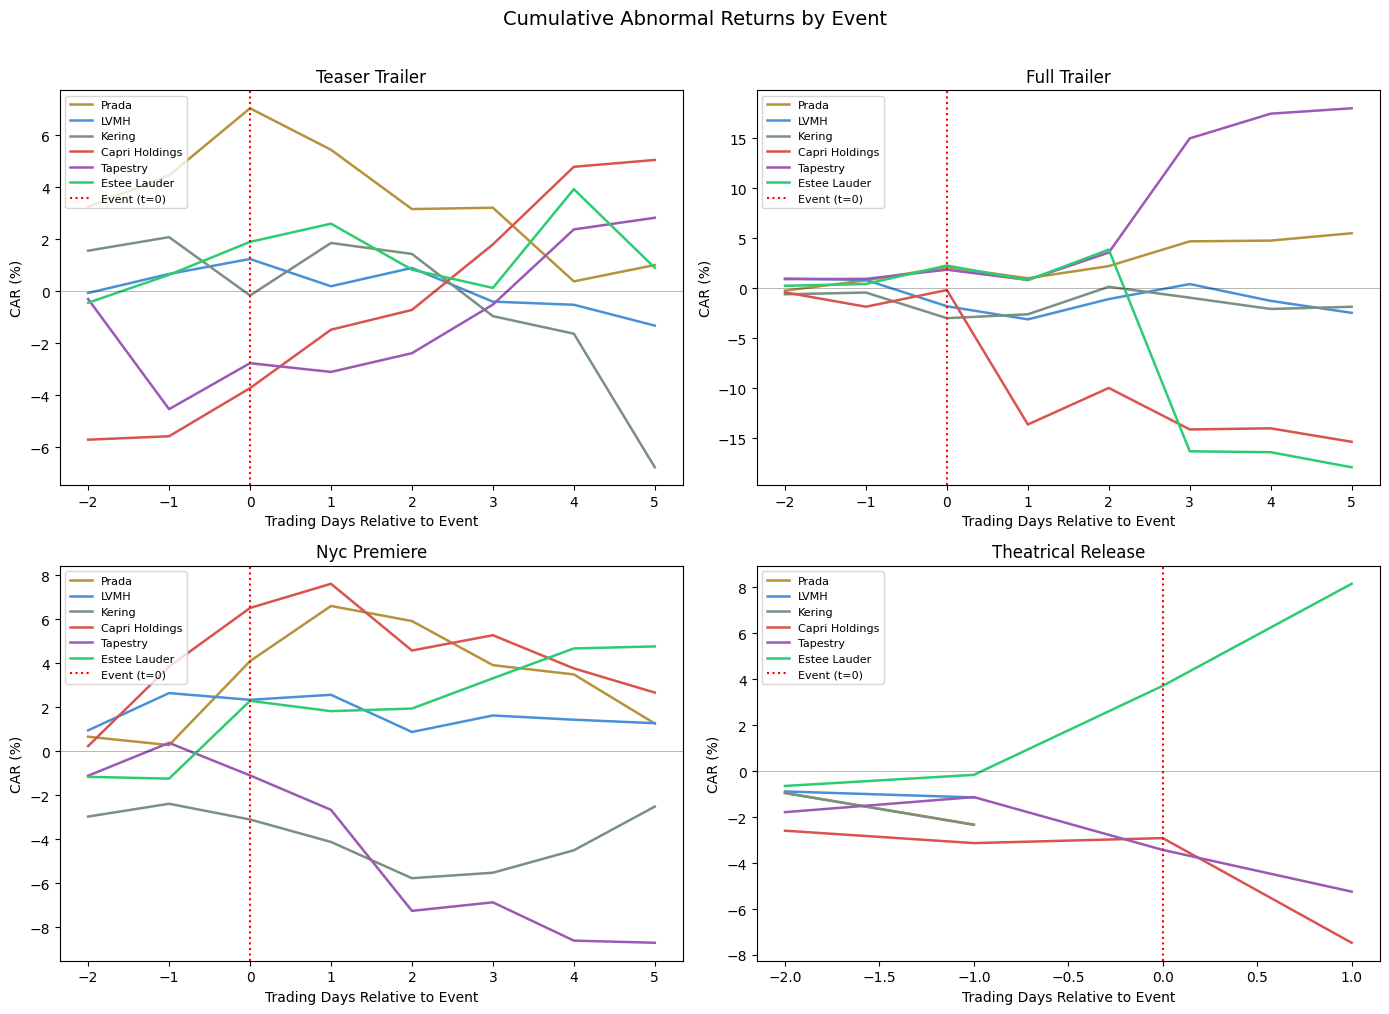

In [4]:
events  = list(EVENT_DATES.keys())
tickers = list(TICKERS.keys())
colors  = ['#B5933A','#4A90D9','#7A9080','#D9534F','#9B59B6','#2ECC71']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, event in zip(axes, events):
    ev_df = car_df[car_df['event'] == event]

    for ticker, color in zip(tickers, colors):
        t_df = ev_df[ev_df['ticker'] == ticker].sort_values('day')
        if t_df.empty:
            continue
        label = TICKERS.get(ticker, ticker)
        ax.plot(t_df['day'], t_df['car'] * 100, label=f'{label}', color=color, linewidth=1.8)

    ax.axvline(0, color='red', linestyle=':', linewidth=1.5, label='Event (t=0)')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(event.replace('_', ' ').title())
    ax.set_xlabel('Trading Days Relative to Event')
    ax.set_ylabel('CAR (%)')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Cumulative Abnormal Returns by Event', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/car_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## 4d. Summary heatmap — total CAR at end of event window

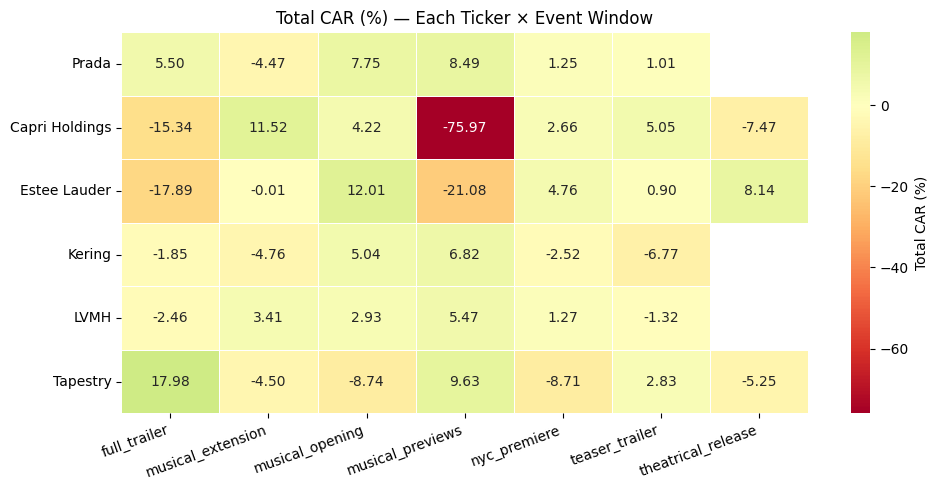

In [5]:
pivot = car_summary.pivot(index='ticker', columns='event', values='total_car') * 100
pivot.index = [TICKERS.get(t, t) for t in pivot.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Total CAR (%)'})
ax.set_title('Total CAR (%) — Each Ticker × Event Window')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/car_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4e. Statistical significance

Stars: *** p<0.01  ** p<0.05  * p<0.10

In [6]:
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

car_summary['stars']          = car_summary['p_value'].apply(stars)
car_summary['total_car_pct']  = (car_summary['total_car'] * 100).round(3)
car_summary['ticker_name']    = car_summary['ticker'].map(TICKERS)

print(car_summary[['ticker_name','event','total_car_pct','t_stat','p_value','stars']]
      .sort_values(['event','total_car_pct'], ascending=[True,False])
      .to_string(index=False))

car_summary.to_csv('../results/tables/car_summary_formatted.csv', index=False)

   ticker_name              event  total_car_pct    t_stat  p_value stars
      Tapestry       full_trailer         17.978  1.631721 0.146758      
         Prada       full_trailer          5.496  1.766421 0.120666      
        Kering       full_trailer         -1.854 -0.423809 0.684424      
          LVMH       full_trailer         -2.456 -0.521868 0.617863      
Capri Holdings       full_trailer        -15.342 -1.045820 0.330408      
  Estee Lauder       full_trailer        -17.886 -0.854750 0.420977      
Capri Holdings  musical_extension         11.518  1.248354 0.252035      
          LVMH  musical_extension          3.414  0.626147 0.551082      
  Estee Lauder  musical_extension         -0.011 -0.001126 0.999133      
         Prada  musical_extension         -4.474 -0.907411 0.394354      
      Tapestry  musical_extension         -4.499 -1.314089 0.230239      
        Kering  musical_extension         -4.760 -1.063007 0.323069      
  Estee Lauder    musical_opening     